# Banking Fraud Anomaly Detection - Solved Version

This notebook compares Isolation Forest and One-Class SVM on a synthetic anomaly detection problem.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

plt.style.use("seaborn-v0_8-whitegrid")

# Create a synthetic dataset with a small fraction of anomalous transactions.
n_samples = 2000
outlier_fraction = 0.05

X_normal, _ = make_blobs(n_samples=int(n_samples * (1 - outlier_fraction)), centers=[[0, 0]], cluster_std=1.0, random_state=42)
X_outliers = np.random.uniform(low=-6, high=6, size=(int(n_samples * outlier_fraction), 2))

X = np.vstack([X_normal, X_outliers])
y = np.hstack([np.zeros(len(X_normal), dtype=int), np.ones(len(X_outliers), dtype=int)])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [2]:
# Fit two standard anomaly detection models on the training data.
iso_forest = IsolationForest(contamination=outlier_fraction, random_state=42)
iso_forest.fit(X_train)

oc_svm = OneClassSVM(nu=outlier_fraction, kernel="rbf", gamma=0.1)
oc_svm.fit(X_train)

print("Both models have been trained.")

Both models have been trained.


In [3]:
# Convert the native anomaly labels to the fraud/no-fraud convention before evaluation.
def evaluate_model(model, X_eval, y_eval, model_name):
    y_pred_raw = model.predict(X_eval)
    y_pred = np.array([1 if x == -1 else 0 for x in y_pred_raw])

    print(f"\n--- {model_name} ---")
    print("Confusion matrix:")
    print(confusion_matrix(y_eval, y_pred))
    print()
    print(classification_report(y_eval, y_pred, target_names=["Normal", "Fraud"]))
    return y_pred


y_pred_if = evaluate_model(iso_forest, X_test, y_test, "Isolation Forest")
y_pred_svm = evaluate_model(oc_svm, X_test, y_test, "One-Class SVM")


--- Isolation Forest ---
Confusion matrix:
[[566   4]
 [  5  25]]

              precision    recall  f1-score   support

      Normal       0.99      0.99      0.99       570
       Fraud       0.86      0.83      0.85        30

    accuracy                           0.98       600
   macro avg       0.93      0.91      0.92       600
weighted avg       0.98      0.98      0.98       600


--- One-Class SVM ---
Confusion matrix:
[[565   5]
 [  4  26]]

              precision    recall  f1-score   support

      Normal       0.99      0.99      0.99       570
       Fraud       0.84      0.87      0.85        30

    accuracy                           0.98       600
   macro avg       0.92      0.93      0.92       600
weighted avg       0.99      0.98      0.99       600



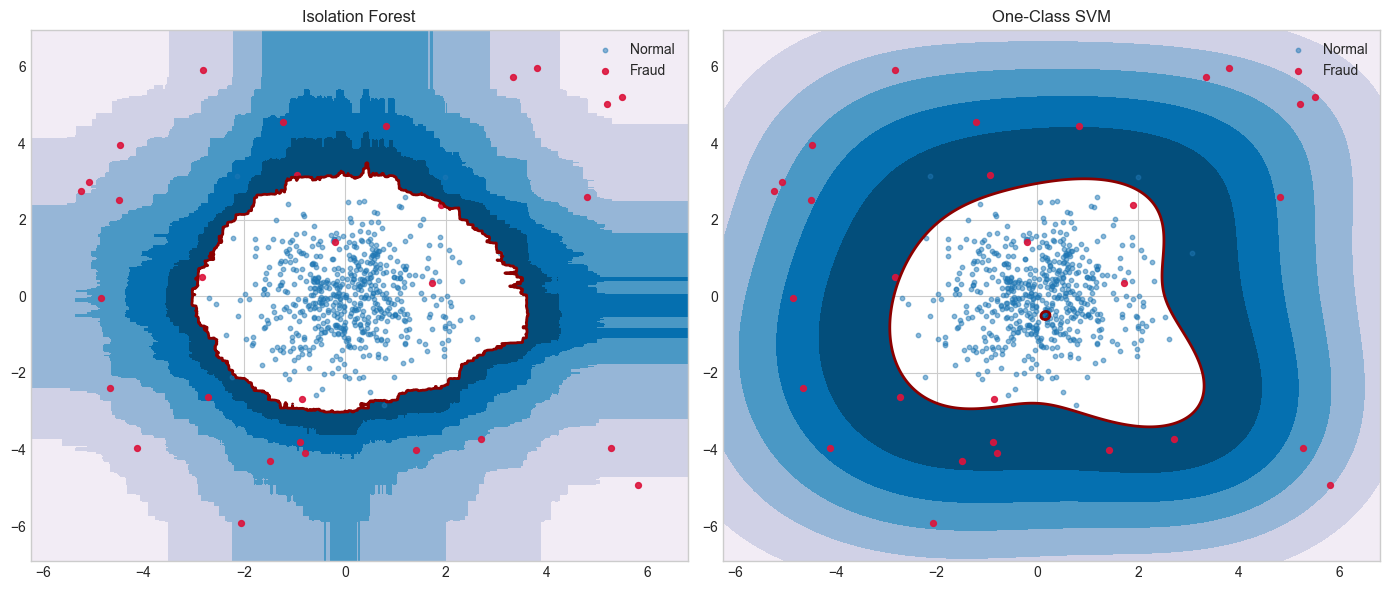

In [4]:
# Plot the learned decision boundaries to compare how each model isolates outliers.
def plot_decision_boundary(model, X_all, y_all, title, subplot_pos):
    plt.subplot(1, 2, subplot_pos)

    h = 0.02
    x_min, x_max = X_all[:, 0].min() - 1, X_all[:, 0].max() + 1
    y_min, y_max = X_all[:, 1].min() - 1, X_all[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = model.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    plt.contourf(xx, yy, Z, levels=np.linspace(Z.min(), 0, 7), cmap=plt.cm.PuBu)
    plt.contour(xx, yy, Z, levels=[0], linewidths=2, colors="darkred")
    plt.scatter(X_all[y_all == 0, 0], X_all[y_all == 0, 1], s=10, alpha=0.5, label="Normal")
    plt.scatter(X_all[y_all == 1, 0], X_all[y_all == 1, 1], s=18, alpha=0.9, color="crimson", label="Fraud")
    plt.title(title)
    plt.legend()

plt.figure(figsize=(14, 6))
plot_decision_boundary(iso_forest, X_test, y_test, "Isolation Forest", 1)
plot_decision_boundary(oc_svm, X_test, y_test, "One-Class SVM", 2)
plt.tight_layout()
plt.show()

## Interpretation

This exercise shows why anomaly detection outputs must be remapped carefully before computing the usual fraud metrics.

Isolation Forest is often easier to tune and more robust on this kind of synthetic setting, while One-Class SVM can be more sensitive to the chosen boundary parameters.